# Introduction to Temperature-based Climate Indices

> [!NOTE]
> The data shown in this repository is for **demonstration purposes only**. To obtain the full datasets for professional analysis, please use the official channels.

This notebook demonstrates how to compute and visualize **temperature-based climate indices** from CMIP6 datasets using the `earthkit-climate` and `xclim` packages.

We'll use:
- **Temperature-based indices**:
  - *DTR*: Daily Temperature Range (Tmax - Tmin)
  - *WSDI*: Warm Spell Duration Index (≥6 consecutive days above 90th percentile)
  - *HDD*: Heating Degree Days (based on temperature below threshold)

We’ll load **ACCESS-CM2 CMIP6 data** for both *historical* and *SSP585* scenarios.

In [10]:
import warnings
from typing import Any, List, Union

import cartopy.crs as ccrs
import earthkit.plots as ekp
import matplotlib.pyplot as plt
import xarray as xr

from earthkit.climate.datasets import load_sample_datasets
from earthkit.climate.indicators.temperature import (
    daily_temperature_range,
    heating_degree_days_approximation,
    warm_spell_duration_index,
)
from earthkit.climate.utils.percentile import calculate_percentile_doy

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
datasets = load_sample_datasets()

## Loading CMIP6 data

We’ll use *daily gridded data* from the ACCESS-CM2 model for maximum (`tasmax`) and minimum (`tasmin`) temperature, for both historical and SSP585 future scenarios.


In [11]:
# Load temperature
tasmin_hist = datasets["tasmin_ACCESS-CM2_historical_reference"]
tasmin_ssp585 = datasets["tasmin_ACCESS-CM2_ssp585_far_future"]

tasmax_hist = datasets["tasmax_ACCESS-CM2_historical_reference"]
tasmax_ssp585 = datasets["tasmax_ACCESS-CM2_ssp585_far_future"]

## Inspect and visualize the raw data

Before computing indices, let’s plot a few example grids to see how the raw variables look.


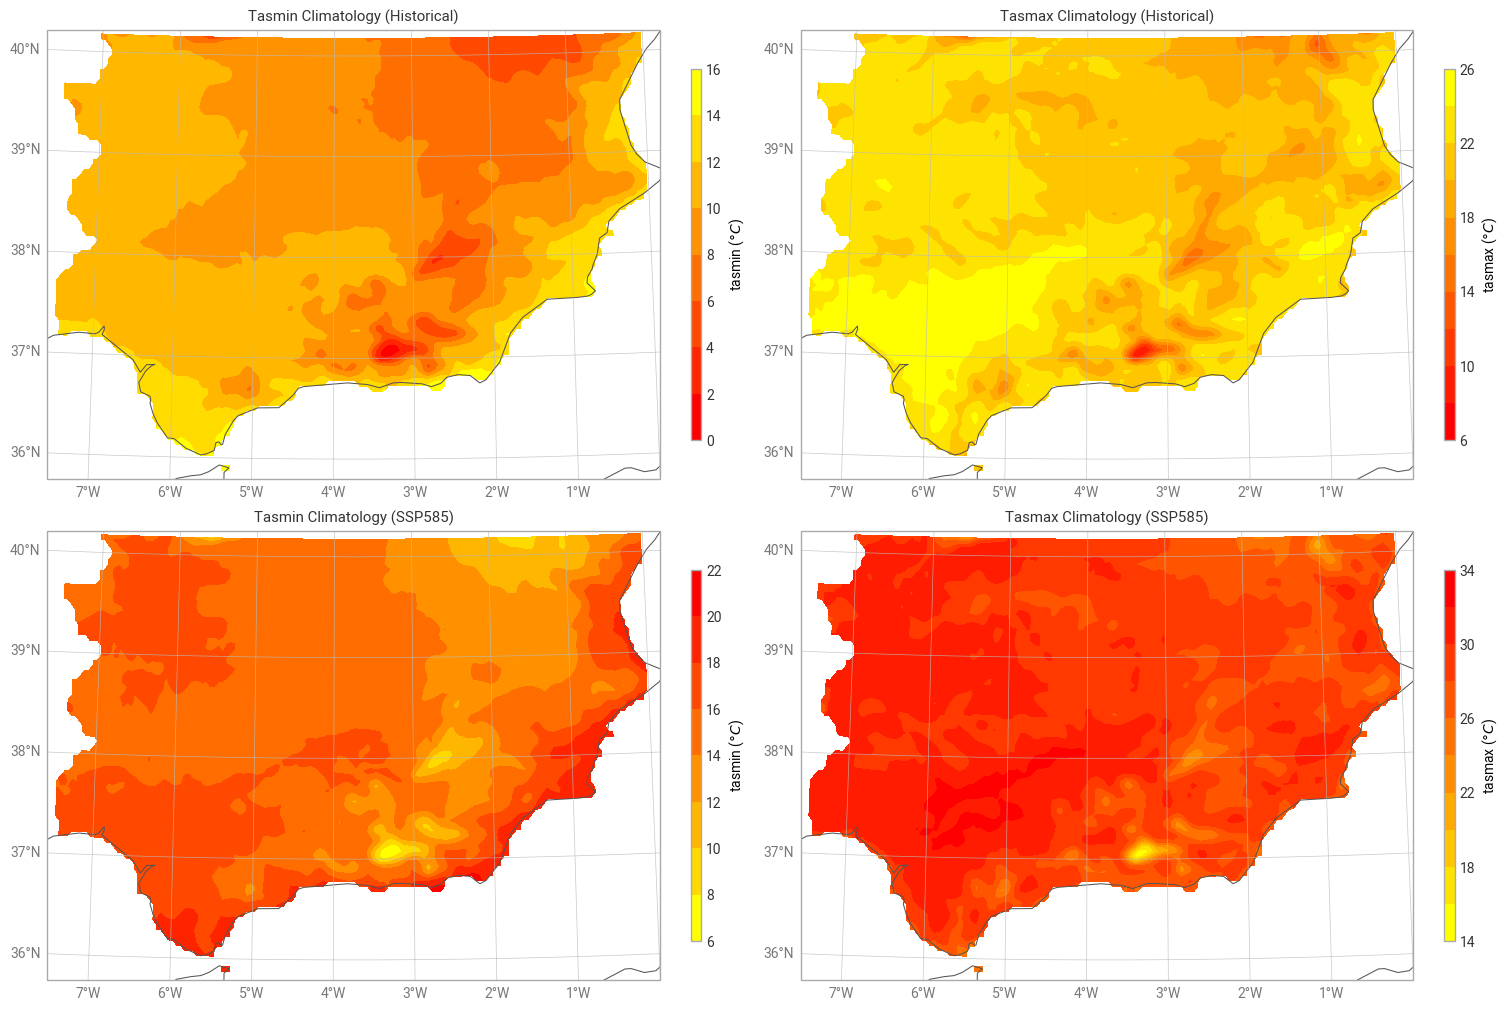

In [12]:
def plot_climatology(
    figure: Any, data: xr.DataArray, row: int, col: int, title: str, colors: Union[str, List[str]], units: str
) -> None:
    """
    Plots a climatological map based on the mean over time.

    Parameters
    ----------
    figure : Any
        The figure object where the map will be added. Typically a
        custom plotting canvas or layout manager.
    data : xarray.DataArray
        The dataset containing atmospheric or oceanic variables.
        Must include a 'time' dimension to calculate the mean.
    row : int
        The row index in the figure layout where the plot will be placed.
    col : int
        The column index in the figure layout where the plot will be placed.
    title : str
        The title text to display above the individual map.
    colors : str or list of str
        The color scale or list of colors to be used by the style engine.
    units : str
        The measurement units for the data (e.g., 'K', 'm/s'), used
        for the style and legend.

    Returns
    -------
    None
    """
    # Se asume que 'domain' está definido globalmente o es accesible
    # en el scope de la función original.
    map_plot = figure.add_map(row=row, column=col, domain=domain)

    style = ekp.styles.Style(colors=colors, units=units)

    # Cálculo de la climatología (media temporal) y graficado
    map_plot.quickplot(data.mean("time"), style=style)

    # Elementos geográficos y estéticos
    map_plot.coastlines()
    map_plot.gridlines()
    map_plot.legend(location="right")
    map_plot.title(title)


# Define domain (Southern Spain)
domain = [-7.5, 0, 35.8, 40.2]

# Create the figure with 2x2 maps
figure = ekp.Figure(
    crs=ccrs.NearsidePerspective(central_longitude=-3.75, central_latitude=38.0), rows=2, columns=2, size=(15, 10)
)

# HISTORICAL
plot_climatology(figure, tasmin_hist, 0, 0, "tasmin Climatology (Historical)", "autumn", "celsius")
plot_climatology(figure, tasmax_hist, 0, 1, "tasmax Climatology (Historical)", "autumn", "celsius")

# SSP585
plot_climatology(figure, tasmin_ssp585, 1, 0, "tasmin Climatology (SSP585)", "autumn_r", "celsius")
plot_climatology(figure, tasmax_ssp585, 1, 1, "tasmax Climatology (SSP585)", "autumn_r", "celsius")

figure.show()

## Compute Daily Temperature Range (DTR)

**DTR** is simply the difference between the daily maximum and minimum temperature. We'll compute it for the SSP585 scenario.


In [13]:
dtr = daily_temperature_range(tasmax=tasmax_ssp585, tasmin=tasmin_ssp585)
dtr

<xarray.DataArray 'dtr' (time: 30, lat: 88, lon: 150)> Size: 2MB
dask.array<where, shape=(30, 88, 150), dtype=float32, chunksize=(3, 40, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B 2.0
Attributes:
    units_metadata:  temperature: difference
    units:           K
    cell_methods:     time range within days time: mean over days
    history:         [2026-03-20 15:44:26] dtr: DTR(tasmin=tasmin, tasmax=tas...
    standard_name:   air_temperature
    long_name:       Mean diurnal temperature range
    description:     Annual mean diurnal temperature range.

## Compute Warm Spell Duration Index (WSDI)

**WSDI** identifies periods of at least 6 consecutive days where the daily maximum temperature exceeds the 90th percentile of the historical reference period (calculated per day of year).


In [14]:
# WSDI (using historical baseline)
# Calculate 90th percentile from historical data
tasmax_per = calculate_percentile_doy(tasmax_hist, variable="tasmax", percentile=90)

# Merge percentile with target dataset
ds_merged = tasmax_ssp585.merge(tasmax_per)

wsdi = warm_spell_duration_index(ds=ds_merged)

wsdi

<xarray.DataArray 'warm_spell_duration_index' (time: 30, lat: 88, lon: 150)> Size: 3MB
dask.array<where, shape=(30, 88, 150), dtype=float64, chunksize=(1, 14, 15), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B 2.0
Attributes:
    climatology_bounds:  ['1971-01-01', '2000-12-31']
    window:              5
    alpha:               0.3333333333333333
    beta:                0.3333333333333333
    history:             [2026-03-20 15:44:28] warm_spell_duration_index: WAR...
    units:               days
    cell_methods:         time: sum over days
    standard_name:       number_of_days_with_air_temperature_above_threshold
    long_name:           Number of days with at least 6 consecutive days wher...
    description:         Annual number of days with at least 6 consecutive da...

## Compute Heating Degree Days (HDD)

**HDD** is the annual cumulative sum of temperature degrees for daily mean temperatures below a threshold (commonly 17.0°C). This version uses an approximation based on Tmin and Tmax.


In [15]:
tas_da = (tasmax_ssp585["tasmax"] + tasmin_ssp585["tasmin"]) / 2

hdd = heating_degree_days_approximation(
    tasmax_ssp585.tasmax,
    tasmin=tasmin_ssp585.tasmin,
    tas=tas_da,
)
hdd

<xarray.DataArray 'heating_degree_days_approximation' (time: 30, lat: 88,
                                                       lon: 150)> Size: 2MB
dask.array<where, shape=(30, 88, 150), dtype=float32, chunksize=(3, 40, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B 2.0
Attributes:
    units:           K days
    units_metadata:  temperature: difference
    cell_methods:     time: sum over days
    history:         [2026-03-20 15:44:28] heating_degree_days_approximation:...
    standard_name:   integral_of_air_temperature_deficit_wrt_time
    long_name:       Cumulative sum of temperature degrees for daily temperat...
    description:     Annual cumulative heating degree days (temperature below...

## Visualization of Temperature Indices

Finally, let's visualize the climatologies of these temperature indices across our domain.


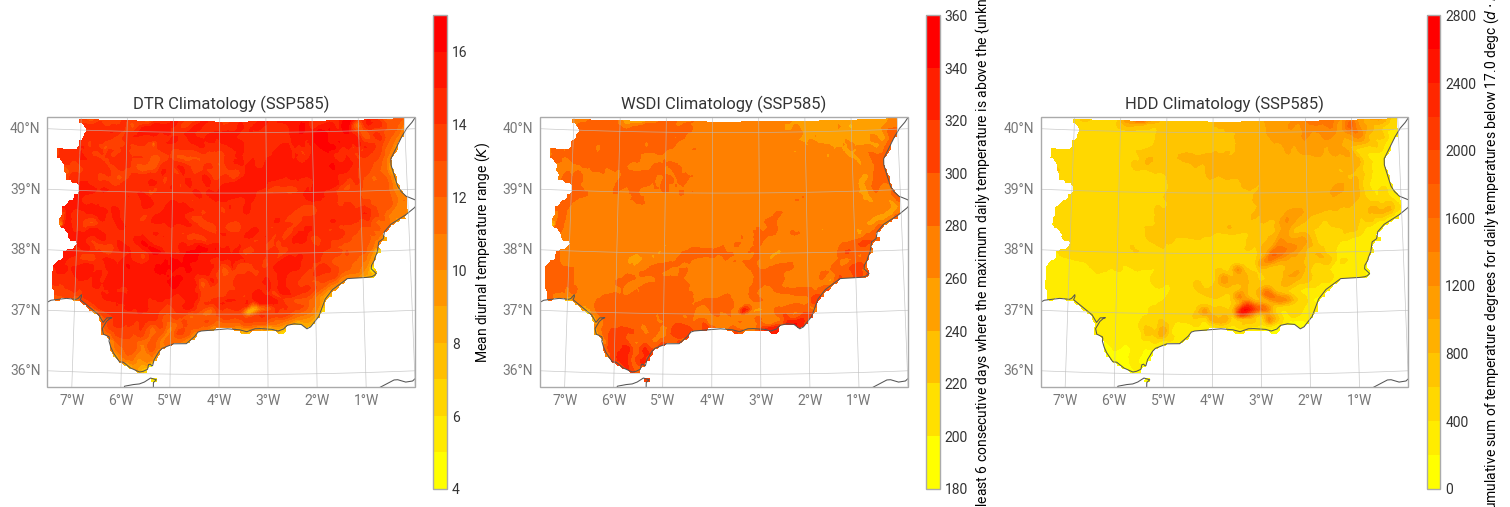

In [16]:
# Create the figure with 1x3 maps
figure = ekp.Figure(
    crs=ccrs.NearsidePerspective(central_longitude=-3.75, central_latitude=38.0), rows=1, columns=3, size=(15, 6)
)

# PLOT: Each index climatology using the helper function
plot_climatology(figure, dtr, 0, 0, "DTR Climatology (SSP585)", "autumn_r", "K")
plot_climatology(figure, wsdi, 0, 1, "WSDI Climatology (SSP585)", "autumn_r", "days")
plot_climatology(figure, hdd, 0, 2, "HDD Climatology (SSP585)", "autumn_r", "K days")

figure.show()